# Titanic Survival Prediction using Machine Learning

## Objective
The goal of this project is to predict whether a passenger survived the Titanic disaster based on features such as age, gender, class, and fare.

This is a binary classification problem.

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection and Processing

In [213]:
titanic_data = pd.read_csv("data/titanic.csv")

In [214]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Description

The dataset contains passenger details such as:

- Pclass (ticket class)
- Sex (gender)
- Age
- SibSp (siblings/spouses aboard)
- Parch (parents/children aboard)
- Fare
- Embarked

Target variable:
- Survived (0 = No, 1 = Yes)

In [215]:
titanic_data.shape

(891, 12)

In [216]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [217]:
# missing values
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handling the missing values

In [218]:
# drop the cabin column from the data frame
titanic_data = titanic_data.drop(columns="Cabin",axis=1)

In [219]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [220]:
# replacing the missing values in Age
titanic_data["Age"].fillna(titanic_data["Age"].mean(),inplace=True)

/tmp/ipykernel_6262/2786615063.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data["Age"].fillna(titanic_data["Age"].mean(),inplace=True)


In [221]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [222]:
titanic_data['Embarked'].mode()

,Embarked
0,S


In [223]:
titanic_data.fillna(titanic_data['Embarked'].mode()[0],inplace=True)

In [224]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Data Analysis

In [225]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [226]:
# finding the no of people survived
titanic_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [227]:
titanic_data['Sex'].value_counts()

,count
Sex,
male,577
female,314


Data Visualisation

In [228]:
sns.set()

<Axes: xlabel='Survived', ylabel='count'>

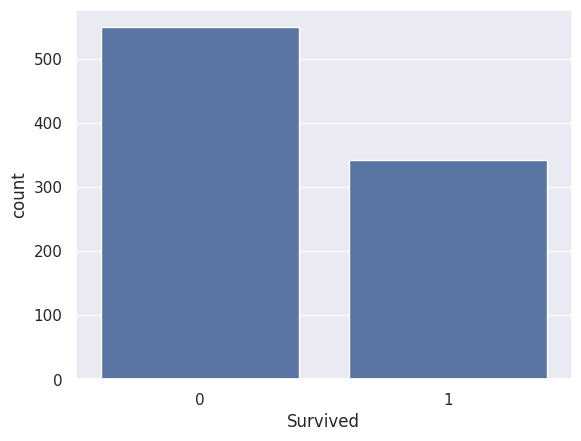

In [229]:
# making a count plot for "Survived" column
sns.countplot(x='Survived', data=titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

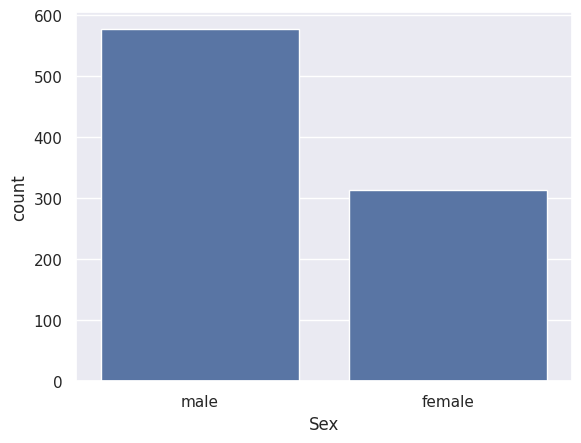

In [230]:
sns.countplot(x="Sex",data = titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

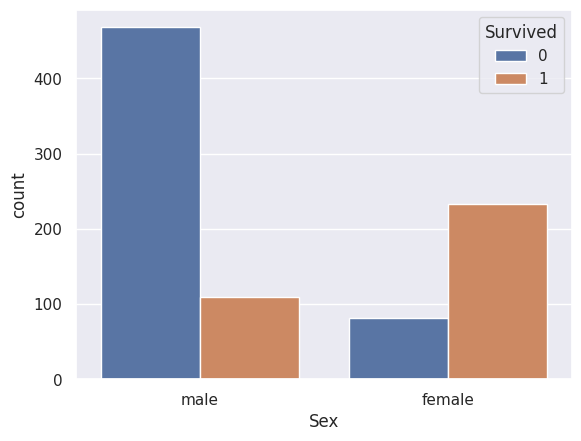

In [231]:
# number of survivors Gender wise
sns.countplot(x="Sex",hue="Survived",data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

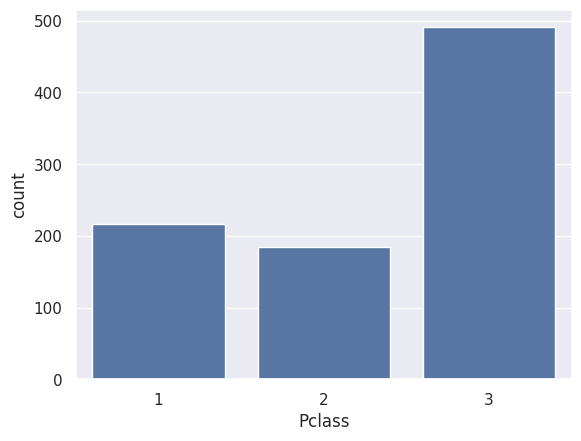

In [232]:
# making a countplot for pclass
sns.countplot(x="Pclass",data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

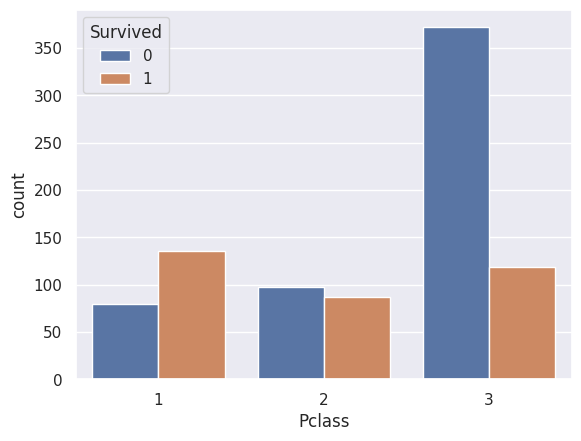

In [233]:
sns.countplot(x="Pclass",hue="Survived",data=titanic_data)

In [234]:
titanic_data.replace({"Sex":{"male":0,"female":1},"Embarked":{"S":0,"C":1,"Q":2}},inplace = True)

/tmp/ipykernel_6262/2448260651.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({"Sex":{"male":0,"female":1},"Embarked":{"S":0,"C":1,"Q":2}},inplace = True)


In [235]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


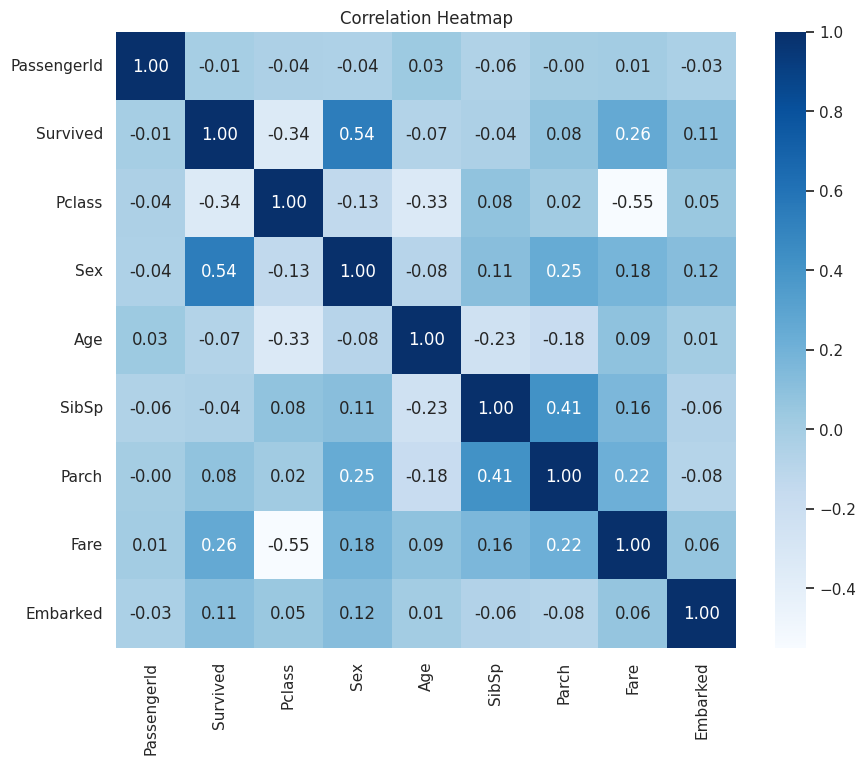

In [236]:
plt.figure(figsize=(10,8))
numeric_data = titanic_data.select_dtypes(include=["number"])
sns.heatmap(numeric_data.corr(), fmt=".2f", annot=True,cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

In [237]:
X = titanic_data.drop(columns=["PassengerId","Name","Ticket","Survived"],axis=1)
Y= titanic_data["Survived"]

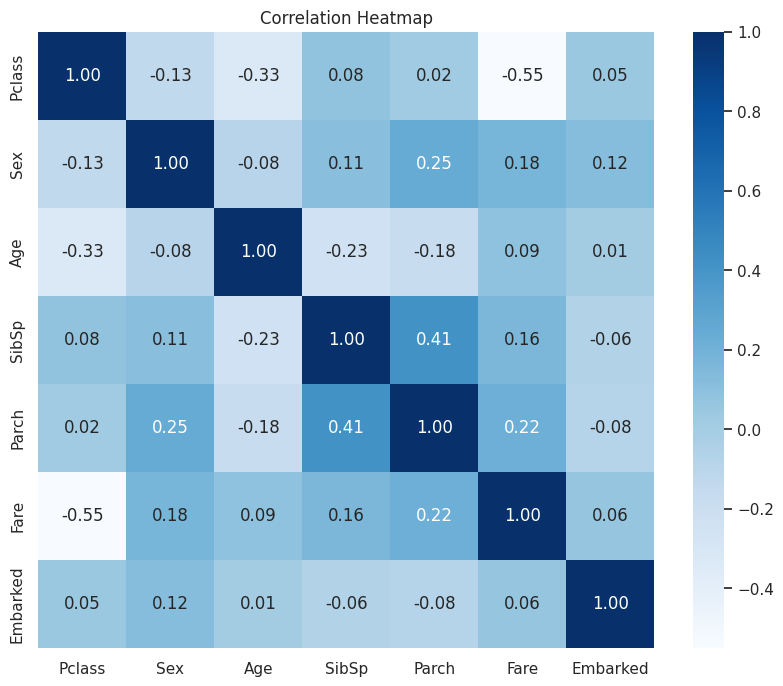

In [238]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(),cbar=True,square=True,fmt='.2f',annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

## Features and Target

X contains input features  
Y contains survival label

In [239]:
print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

Feature shape: (891, 7)
Target shape: (891,)


In [240]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [241]:
print(X.shape,X_train.shape,X_test.shape)

(891, 7) (712, 7) (179, 7)


In [242]:
model = LogisticRegression()

In [243]:
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [244]:
training_data_prediction = model.predict(X_train)

training_data_accuracy = accuracy_score(Y_train,training_data_prediction)

print(f"Accuracy score of training data : {training_data_accuracy}")

Accuracy score of training data : 0.8075842696629213


In [245]:
test_data_prediction = model.predict(X_test)

test_data_accuracy = accuracy_score(Y_test,test_data_prediction)

print(f"Accuracy score of test data : {test_data_accuracy}")

Accuracy score of test data : 0.7821229050279329


In [246]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test, test_data_prediction))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       100
           1       0.84      0.62      0.72        79

    accuracy                           0.78       179
   macro avg       0.80      0.77      0.77       179
weighted avg       0.79      0.78      0.78       179



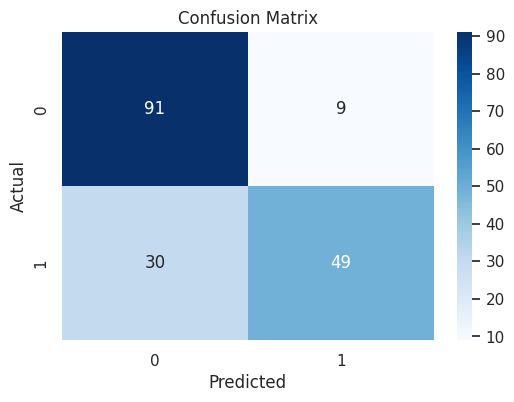

In [247]:
cm = confusion_matrix(Y_test, test_data_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [248]:
importance = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,Sex,2.667338
6,Embarked,0.221956
4,Parch,0.009434
5,Fare,0.002214
2,Age,-0.045317
3,SibSp,-0.377352
0,Pclass,-1.128776


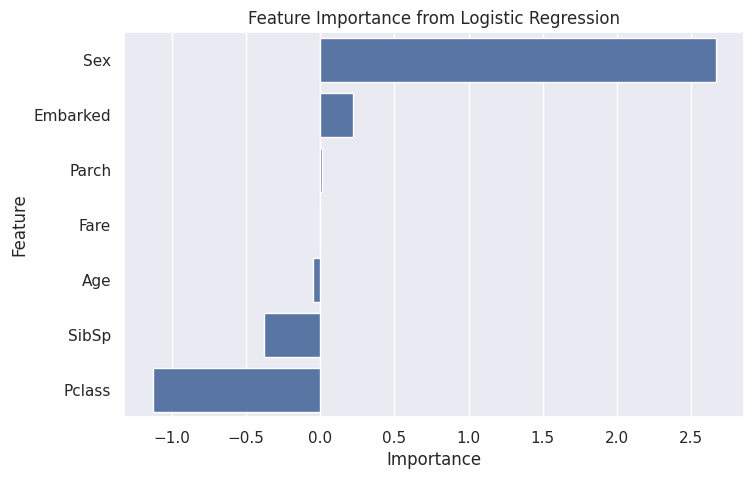

In [249]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance from Logistic Regression")
plt.show()

In [250]:
input_data=(X.iloc[0])

input_data_as_numpy = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy.reshape(1,-1)

prediction = model.predict(input_data_reshaped)

print(prediction)

if prediction[0]==0:
  print("Dead")
else:
  print("Alive")

[0]
Dead


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Conclusion

The model predicts survival with reasonable accuracy.

Gender and class are strong indicators of survival.

Future improvements:
- try Random Forest
- try XGBoost